the market buy and sell in medium frequency should be cyclical due to the market participant's position. For daily candle data, we can define the buy and sell volume as 

1. upper wick: sell volume part. and the length is marked as  $v_2$
1. body: buy/sell depend on the direction and the length is marked as $v_1$ with sign indicate the direction
1. lower wick: the buy volume part and the length is marked as $v_0$

so the buy volume then is $ V \cdot (v_0 + \text{sign} (v1))/(P_h - P_L)$

The result has two mode:
1. buy and sell on different direction: short term rotation
1. buy and sell on same direction (especially rose at the same time): big volatile and market regime shift

In [ ]:
from sts.dio.equity import TickerDatabase as Ticker
import plotly.io as pio
import pandas as pd
import numpy as np
from sts.quant.ta.trend import get_trend_score_multi_horizon
from sts.quant.candle import Candle
from sts.stsig.ta.market_regime import BuySellCycle
import os

saved file: ../../../data/market_data/equity/SPY.pkl


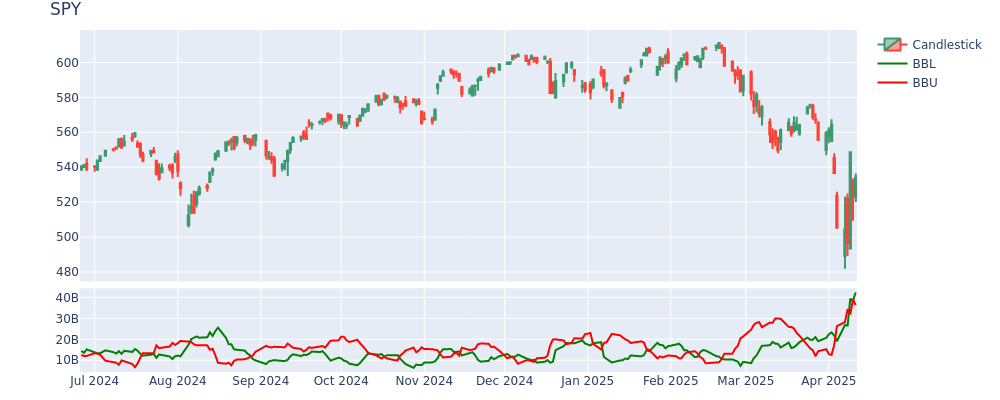

saved file: ../../../data/market_data/equity/QQQ.pkl


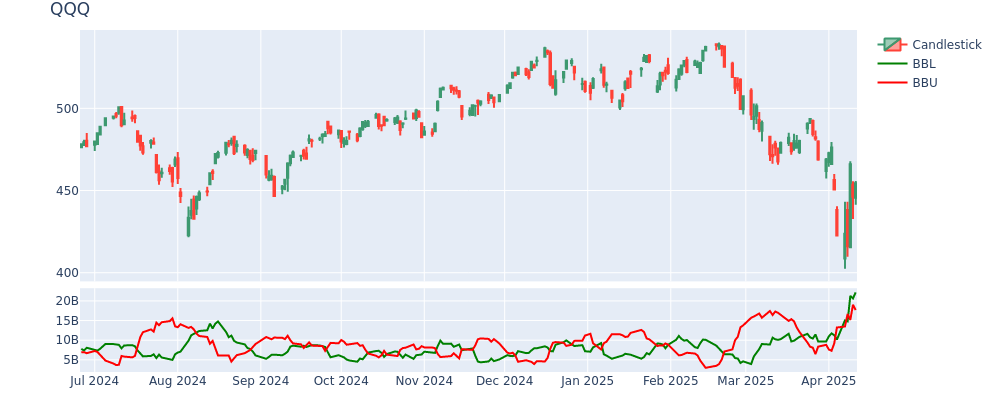

saved file: ../../../data/market_data/equity/IWM.pkl


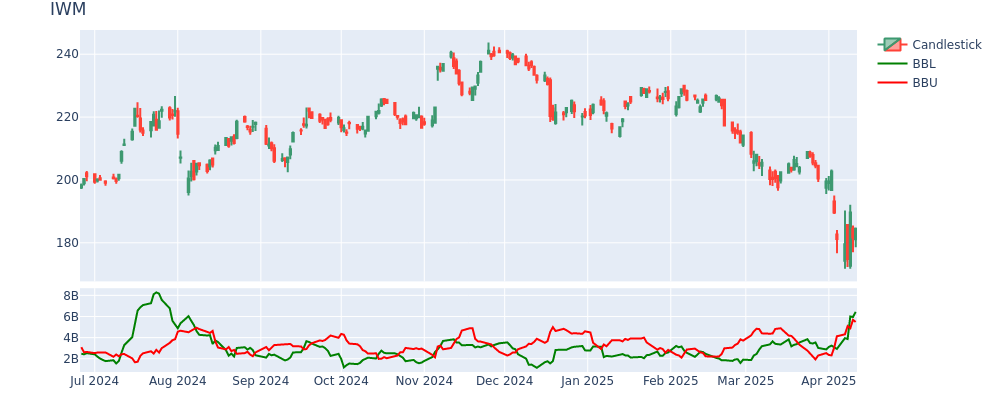

saved file: ../../../data/market_data/equity/GLD.pkl


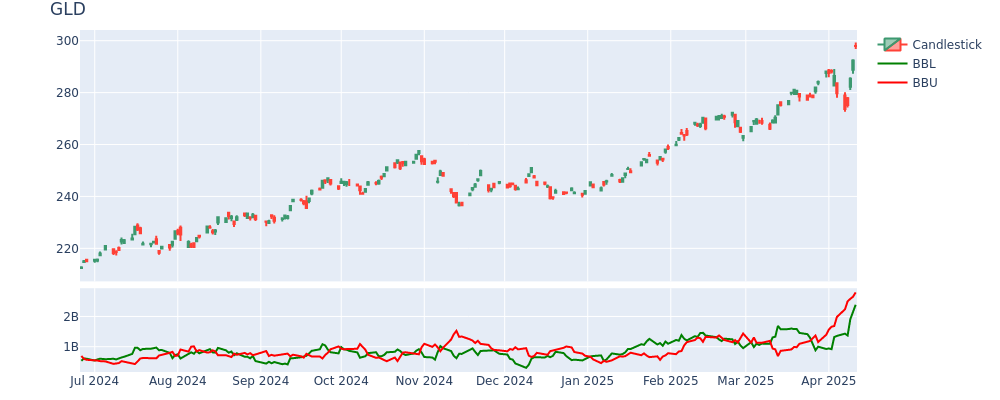

saved file: ../../../data/market_data/equity/SLV.pkl


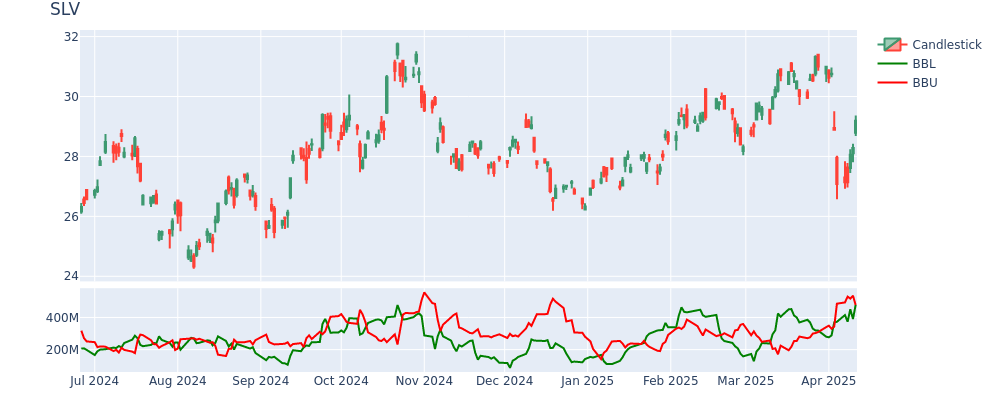

saved file: ../../../data/market_data/equity/CPER.pkl


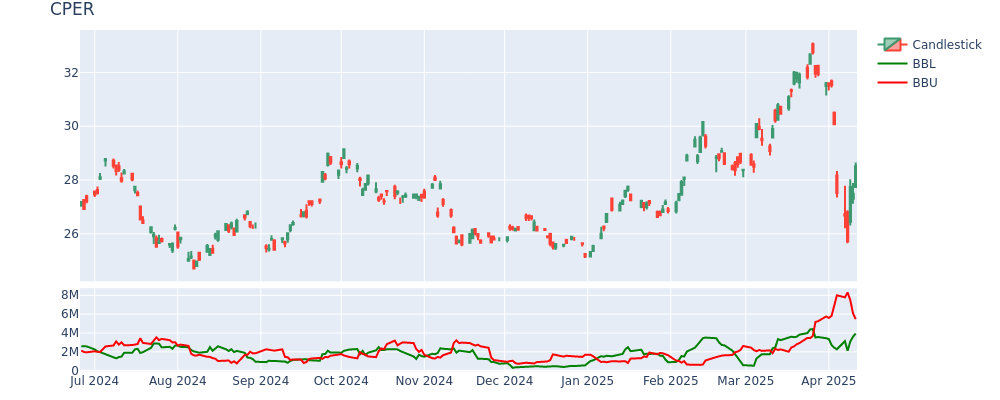

saved file: ../../../data/market_data/equity/USO.pkl


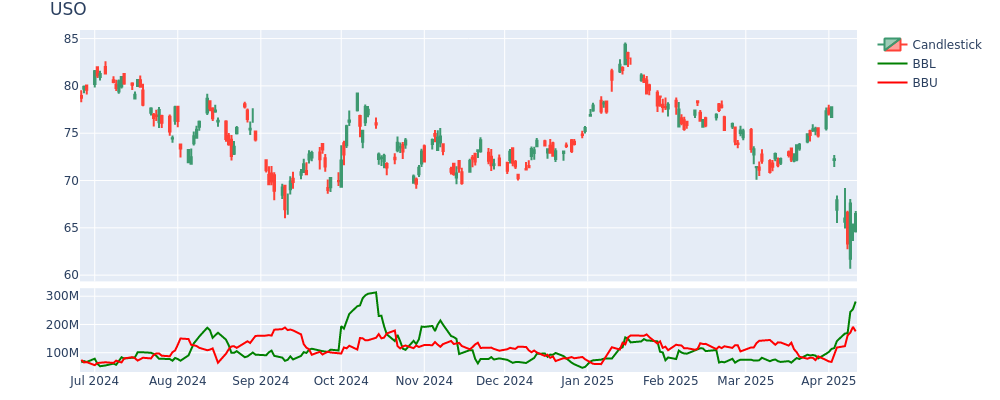

saved file: ../../../data/market_data/equity/TLT.pkl


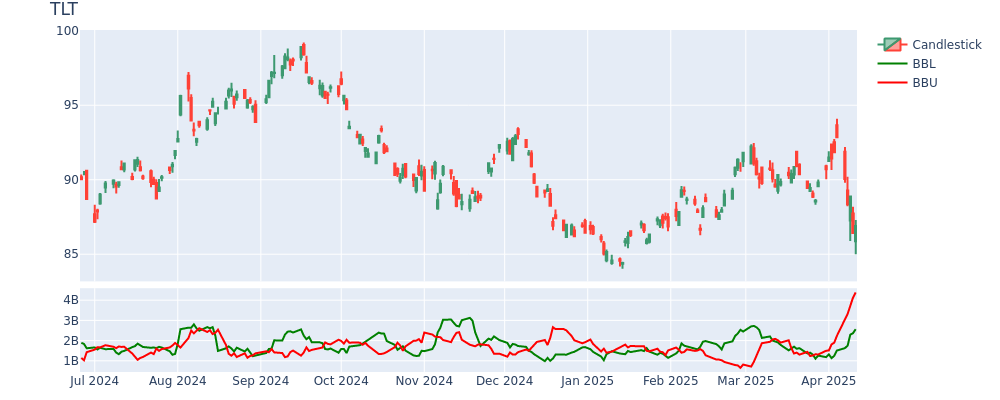

saved file: ../../../data/market_data/equity/KWEB.pkl


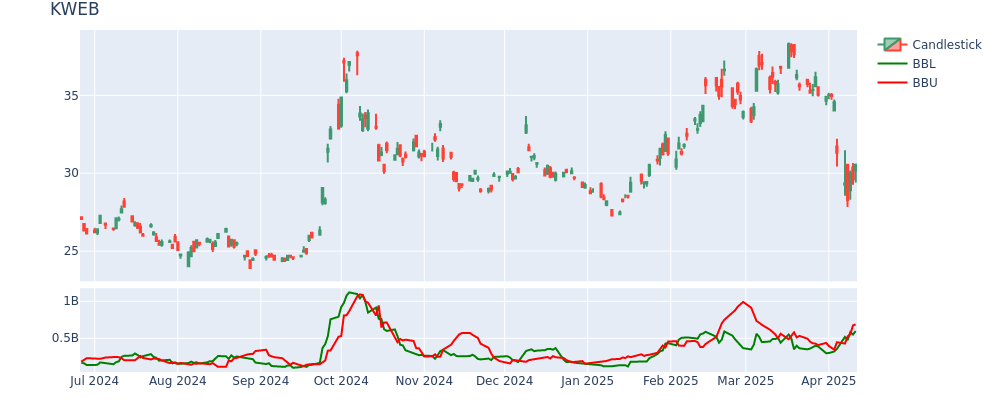

saved file: ../../../data/market_data/equity/MRVL.pkl


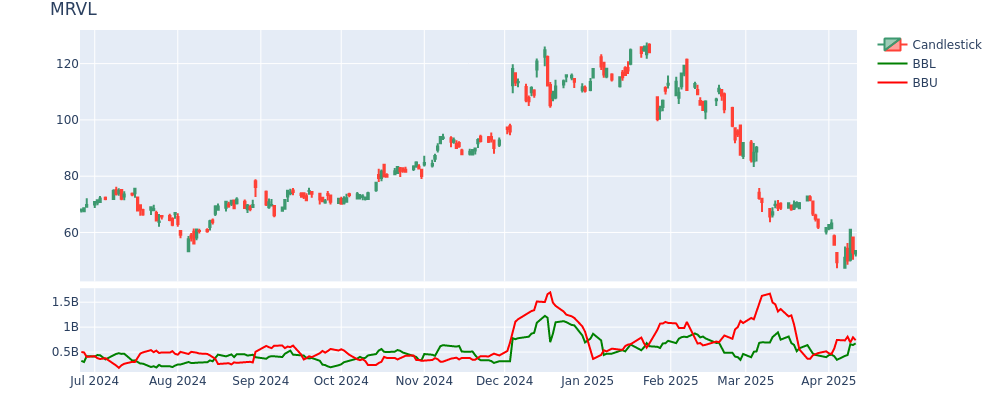

saved file: ../../../data/market_data/equity/ADBE.pkl


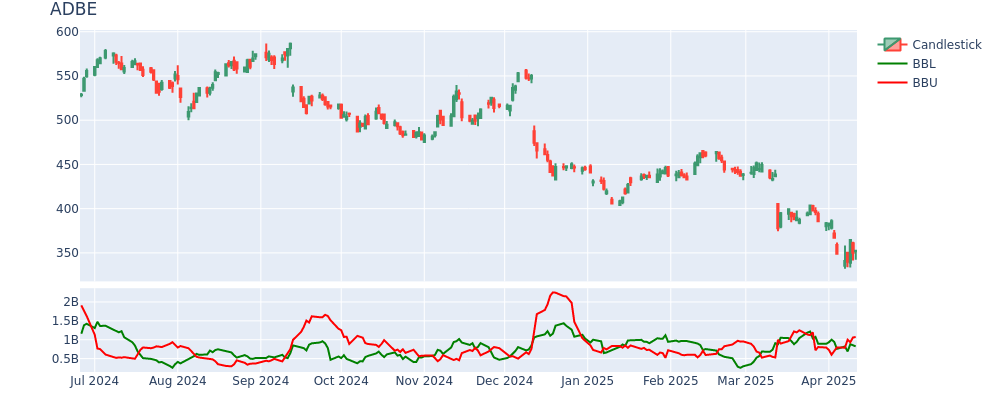

saved file: ../../../data/market_data/equity/ANET.pkl


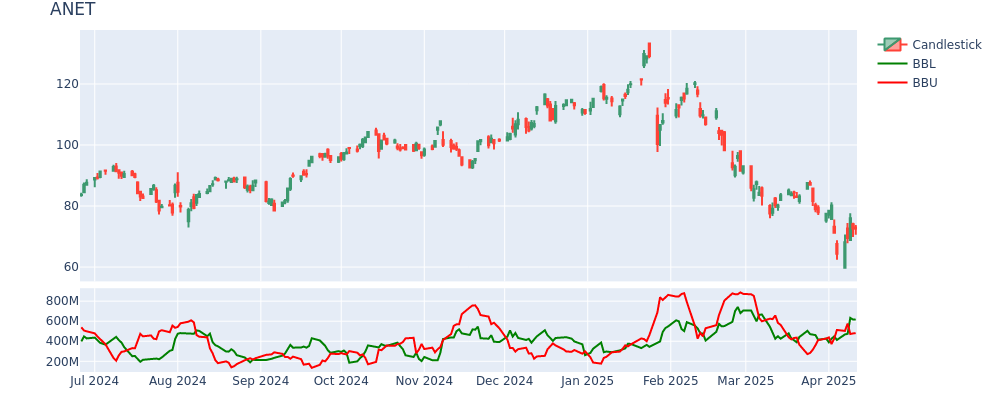

saved file: ../../../data/market_data/equity/PWR.pkl


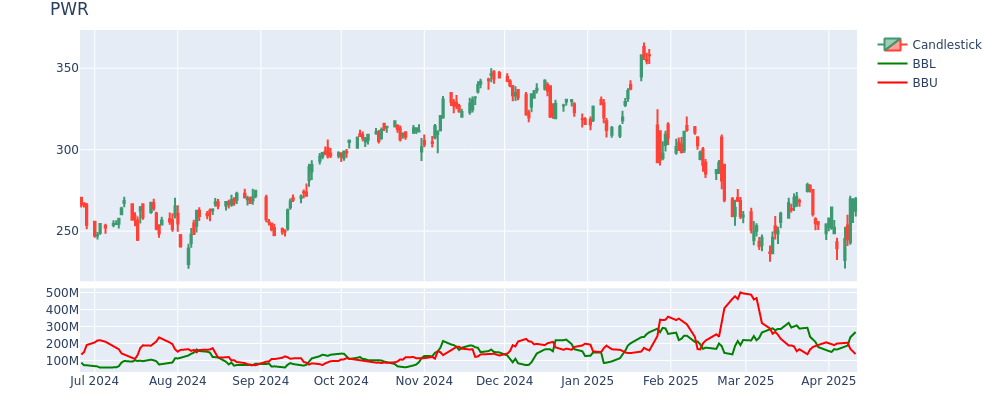

saved file: ../../../data/market_data/equity/AMD.pkl


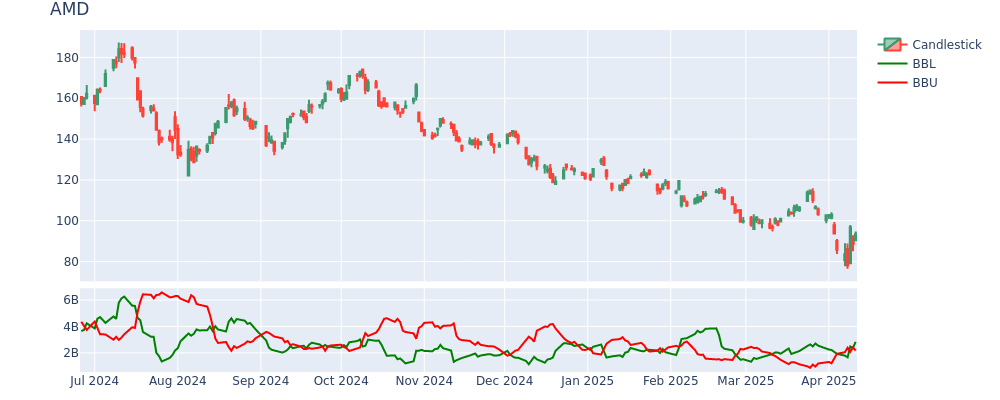

saved file: ../../../data/market_data/equity/GOOGL.pkl


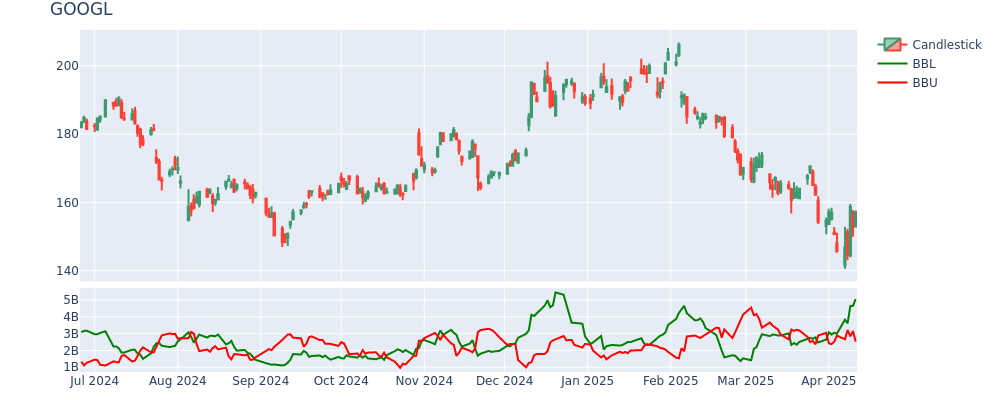

saved file: ../../../data/market_data/equity/NVDA.pkl


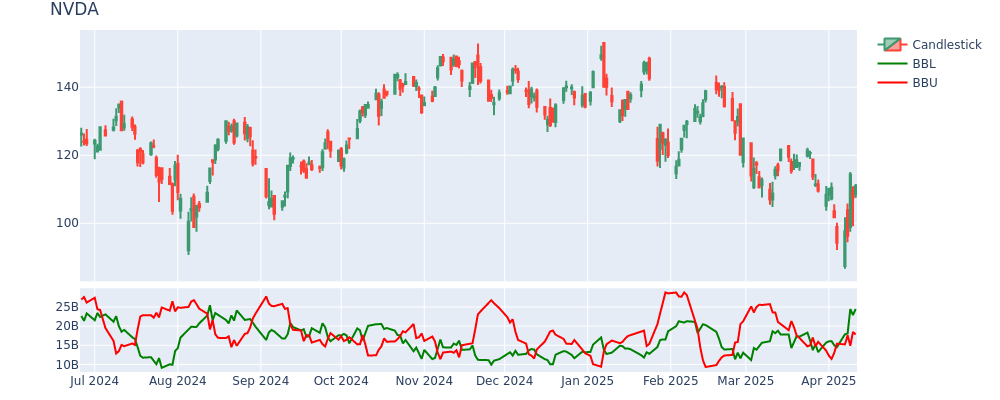

saved file: ../../../data/market_data/equity/ASML.pkl


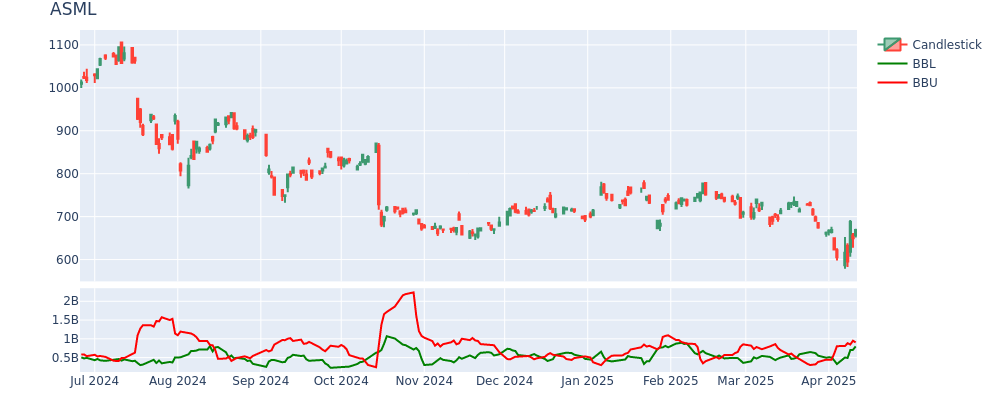

saved file: ../../../data/market_data/equity/TSLA.pkl


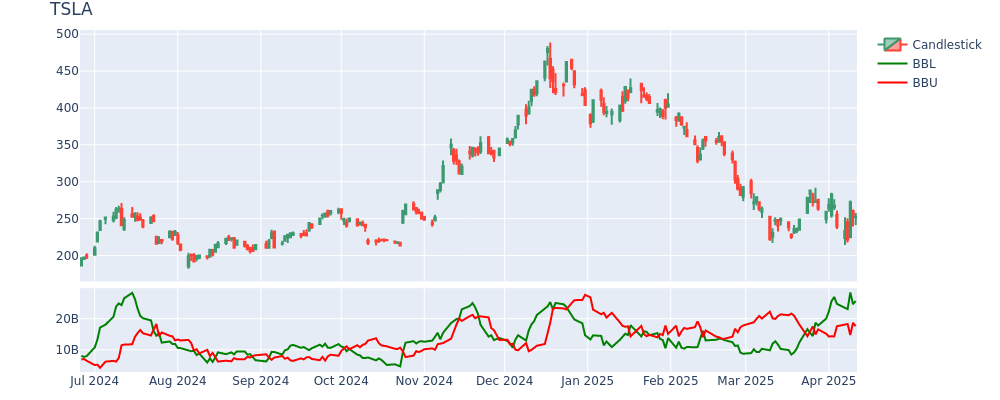

saved file: ../../../data/market_data/equity/PFE.pkl


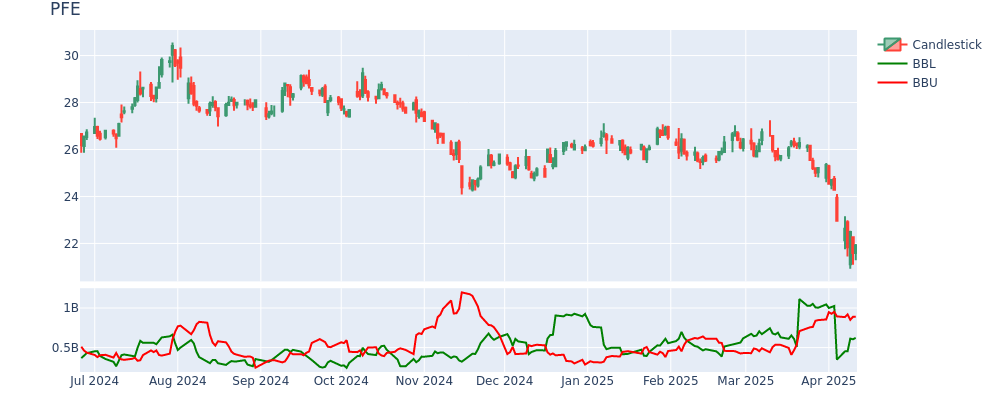

saved file: ../../../data/market_data/equity/IWM.pkl


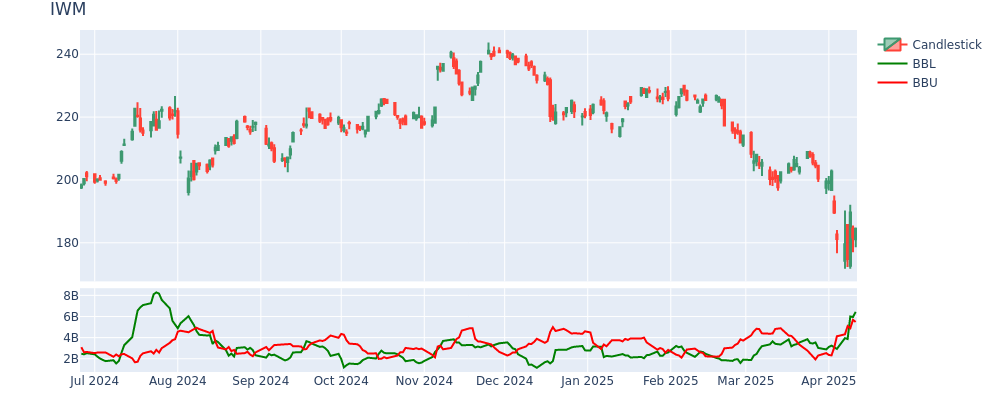

saved file: ../../../data/market_data/equity/AVGO.pkl


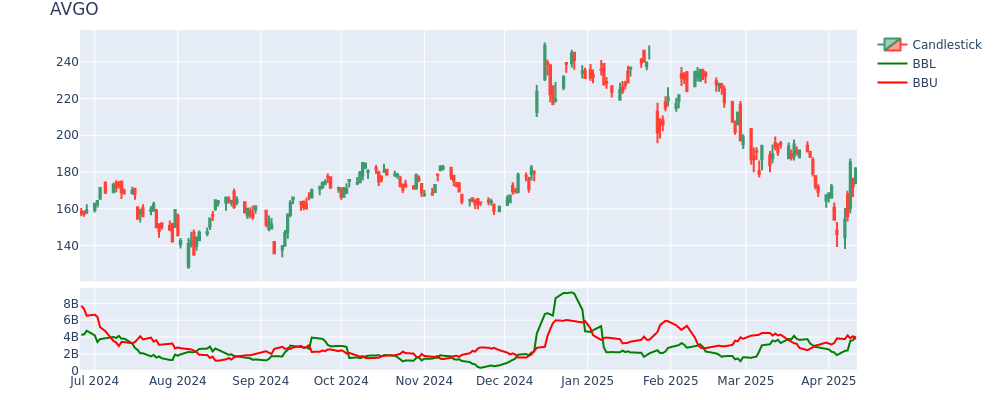

saved file: ../../../data/market_data/equity/FTNT.pkl


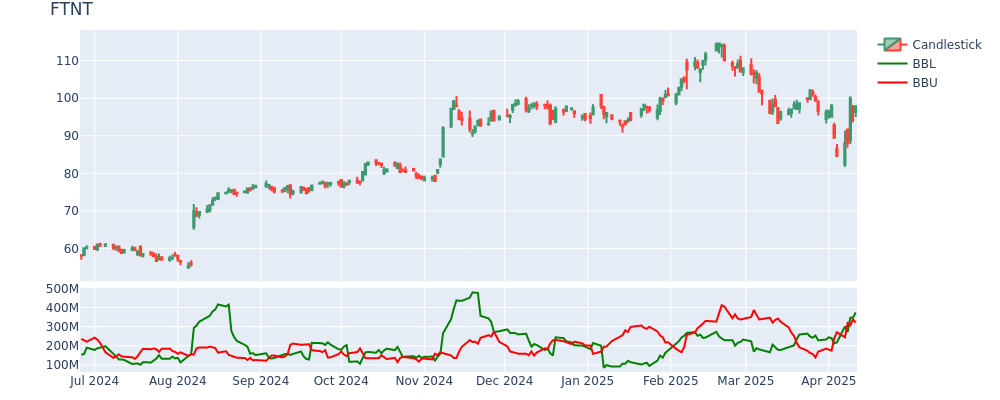

saved file: ../../../data/market_data/equity/MMM.pkl


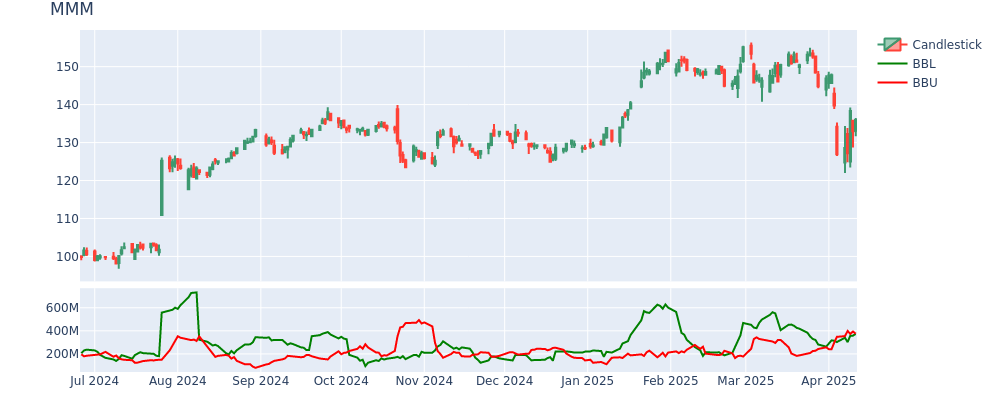

saved file: ../../../data/market_data/equity/JPY=X.pkl


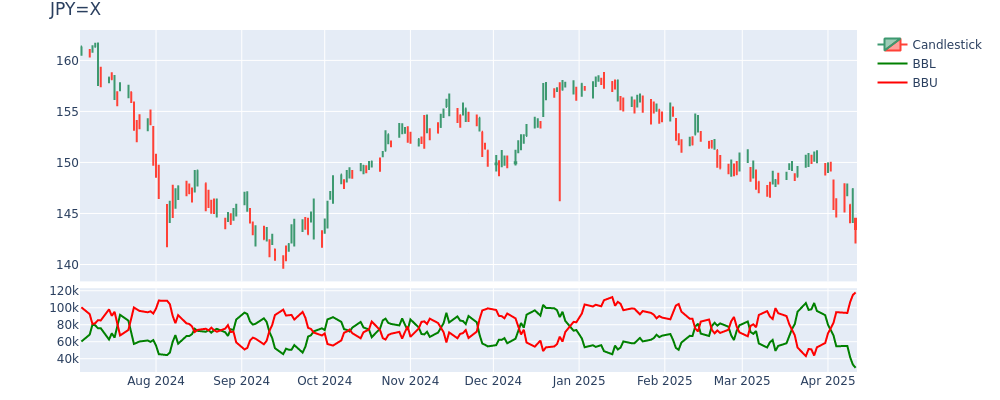

saved file: ../../../data/market_data/equity/GBPUSD=X.pkl


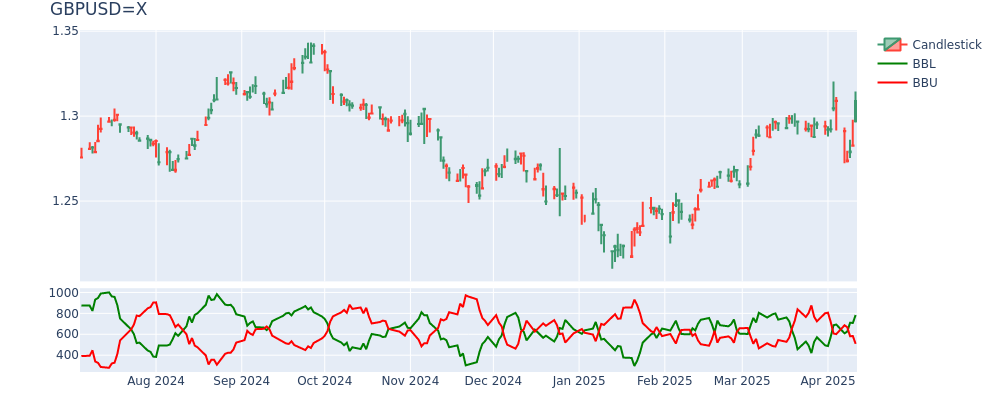

saved file: ../../../data/market_data/equity/AUDUSD=X.pkl


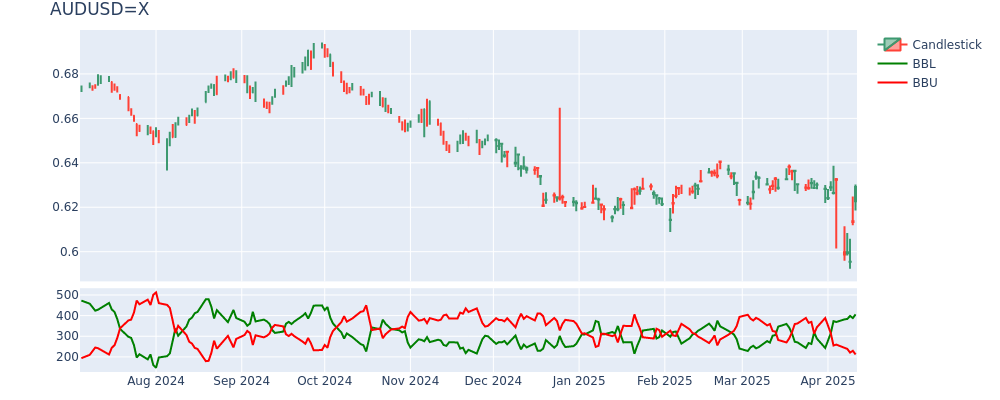

saved file: ../../../data/market_data/equity/EURUSD=X.pkl


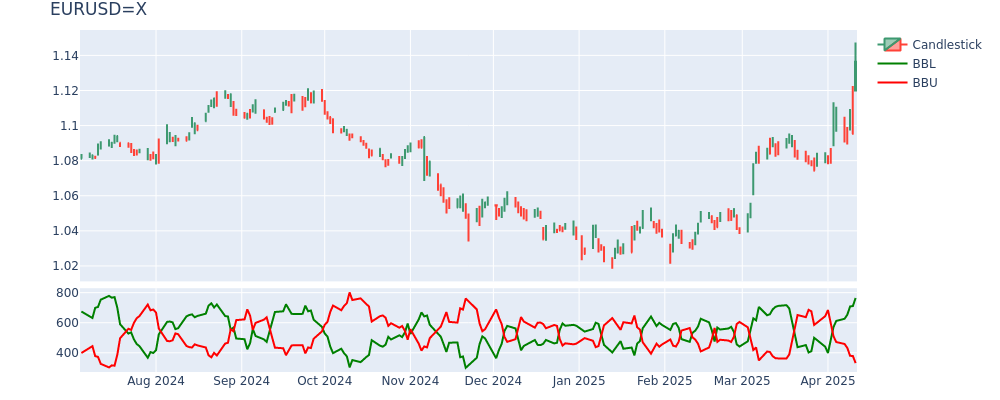

saved file: ../../../data/market_data/equity/CADUSD=X.pkl


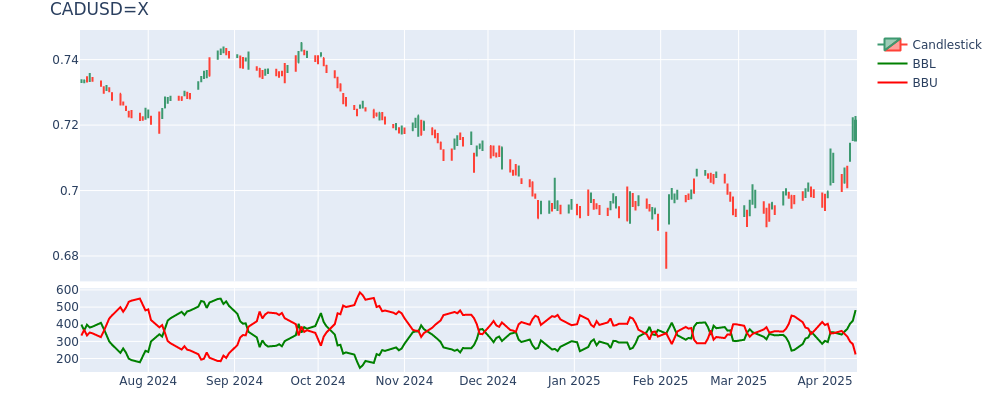

In [ ]:
# ticker = Ticker('^NDX', data_mode = Ticker.DATAMODE.LOCAL, local_data_folder = '../../../data/market_data/' )
pio.renderers.default = os.environ.get("PLOTLY_RENDERER", "png")
regime_dict = {}
resample_rule = "1D"
rule_period_map = {"1D": "2y", "1W": "5y", "1M": "10y"}
period = rule_period_map[resample_rule]
future = ["^SPX", "^NDX", "^RUT", "GC=F", "HG=F", "SI=F", "CL=F", "TLT", "KWEB"]
single_name = [
    "MRVL",
    "ADBE",
    "ANET",
    "PWR",
    "AMD",
    "GOOGL",
    "NVDA",
    "ASML",
    "TSLA",
    "PFE",
    "IWM",
    "AVGO",
    "FTNT",
    "MMM",
]
etf = ["SPY", "QQQ", "IWM", "GLD", "SLV", "CPER", "USO", "TLT", "KWEB"]
fx = ["JPY=X", "GBPUSD=X", "AUDUSD=X", "EURUSD=X", "CADUSD=X"]
for sym in etf + single_name + fx:
    ticker = Ticker(sym)
    df = Candle(ticker.history(period=period))
    if resample_rule != "1D":  # 1D resample is calendar day
        df = df.resample(resample_rule)
    buy_sell_cycle = BuySellCycle(window=10, cons_volume=(True if sym in fx else False))
    buy_sell_cycle.set_data(df)
    fig = buy_sell_cycle.plot(buy_sell_cycle.df.iloc[-200:])
    fig.update_layout(title=sym, height=400, width=1000, margin={"t": 30, "b": 20})
    fig.show()
    regime_dict[sym] = buy_sell_cycle